In [18]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os

from neurolib.models.aln import ALNModel
from neurolib.models.aln_2synapse import ALN_2synapse_Model
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
c_mat = np.zeros(( 2,2 ))     # global coupling matrix: which nodes are coupled?
#c_mat[0,1] = 1.
c_mat[1,0] = 1.               # node 1 receives input from node 0
c_scheme = np.ones(( 2,2 ))   # local coupling sceme, which inputs are coupled locally?
d_mat = np.zeros(( 2,2 ))     # delay matrix: signal transmission from node i to node j
u_mat = np.identity(2)        # global control matrix, diagonal, which nodes are controlled?
u_scheme = np.array([[1.]])   # local control scheme, which inputs are controlled locally?

aln = ALNModel(Cmat=c_mat, Dmat = d_mat)
aln_2syn = ALN_2synapse_Model(Cmat=c_mat, Dmat = d_mat)

N = aln.params.N
models = [aln, aln_2syn]

for model in models:
    model.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
    model.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
    model.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.seem_ext_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
    model.params.seev_ext_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
    model.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
    model.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
    model.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
    model.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
    model.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
    model.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

    model.params.sigma_ou = 0.
    model.params.mue_ou = np.zeros((N))
    model.params.mui_ou = np.zeros((N))
    
    model.params.mue_ext_mean = 0.
    model.params.mui_ext_mean = 0.

In [109]:
def set_params_slow(model):
    # external currents for aE limit cycle (slow)
    model.params.ext_exc_current = 4. * np.ones(( N ))
    model.params.ext_inh_current = 2. * np.ones(( N ))
    
def set_params_fast(model):
    # external currents for EI limit cycle (fast)
    model.params.ext_exc_current = 2.5 * np.ones(( N ))
    model.params.ext_inh_current = 0. * np.ones(( N ))
    
def set_params_up(model):
    # external currents for up state
    model.params.ext_exc_current = 5. * np.ones(( N ))
    model.params.ext_inh_current = 1. * np.ones(( N ))
    
def set_params_down(model):
    # external currents for up state
    model.params.ext_exc_current = 2. * np.ones(( N ))
    model.params.ext_inh_current = 3. * np.ones(( N ))

In [121]:
def plot_aln(model):   
    
    if model.params.name == "aln-2synapse":
        fig, ax = plt.subplots(3, 2, figsize=(18, 12), linewidth=8, edgecolor='grey')   
    else:
        fig, ax = plt.subplots(2, 2, figsize=(18, 8), linewidth=8, edgecolor='grey')
        
    ax[0,0].plot(model.t, model.rates_exc[0,:], label="exc rate node 0")
    ax[0,0].plot(model.t, model.rates_exc[1,:], label="exc rate node 1")
    ax[0,0].legend()
    ax[0,1].plot(model.t, model.rates_inh[0,:], label="inh rate node 0")
    ax[0,1].plot(model.t, model.rates_inh[1,:], label="inh rate node 1")
    ax[0,1].legend()
    ax[1,0].plot(model.t, model.state["seem"][0,:], label="seem node 0")
    ax[1,0].plot(model.t, model.state["seem"][1,:], label="seem node 1")
    ax[1,0].legend()
    ax[1,1].plot(model.t, model.state["seev"][0,:], label="seev node 0")
    ax[1,1].plot(model.t, model.state["seev"][1,:], label="seev node 1")
    ax[1,1].legend()
    if model.params.name == "aln-2synapse":
        ax[2,0].plot(model.t, model.state["seem_ext"][0,:], label="seem ext node 0")
        ax[2,0].plot(model.t, model.state["seem_ext"][1,:], label="seem ext node 1")
        ax[2,0].legend()
        ax[2,1].plot(model.t, model.state["seev_ext"][0,:], label="seev ext node 0")
        ax[2,1].plot(model.t, model.state["seev_ext"][1,:], label="seev ext node 1")
        ax[2,1].legend()

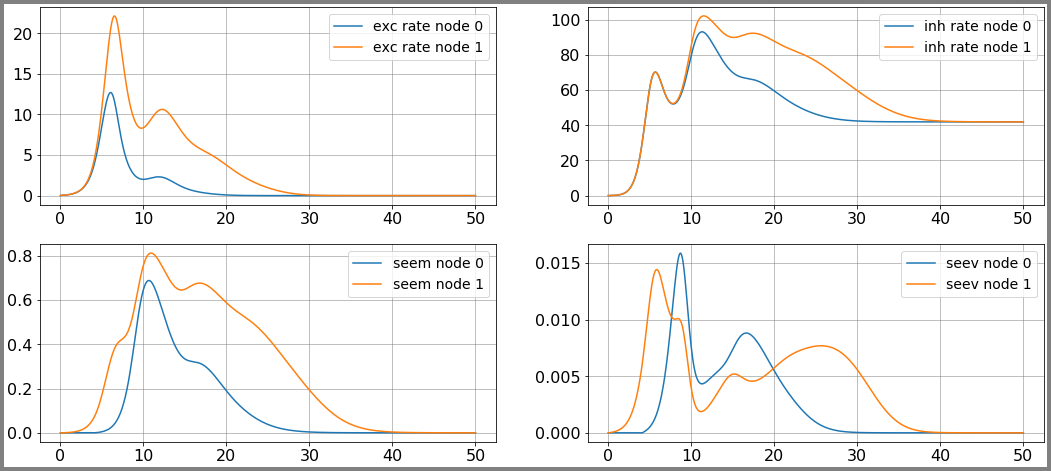

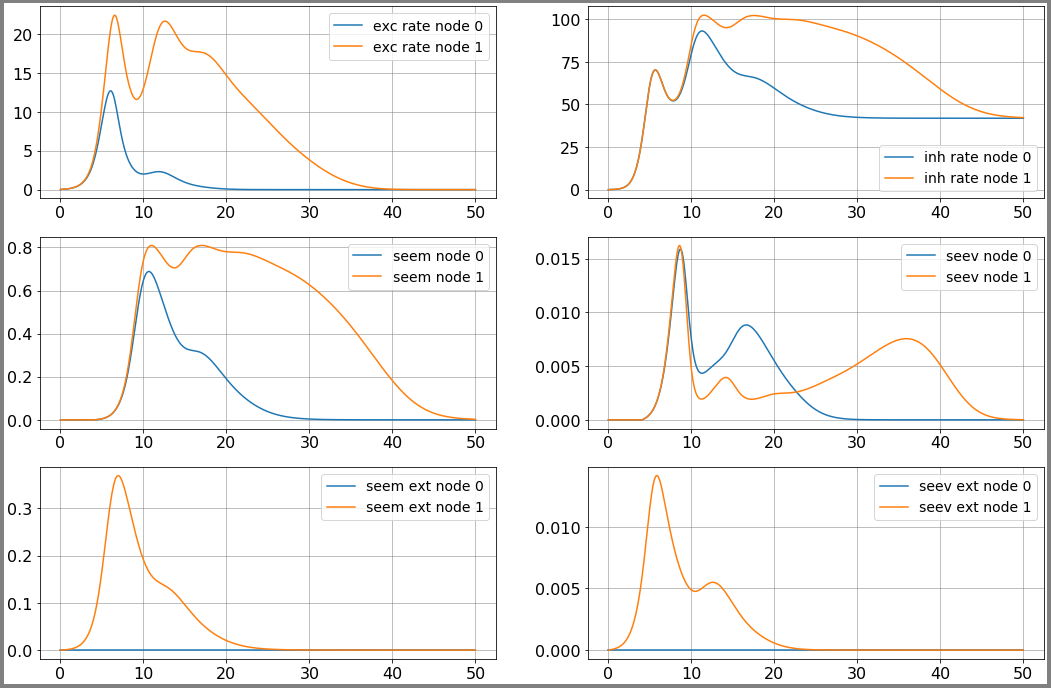

In [127]:
# down
dur = 50

for m in range(len(models)):
    models[m].params.duration = dur
    set_params_down(models[m])
    models[m].run(control=models[m].getZeroControl())
    plot_aln(models[m])


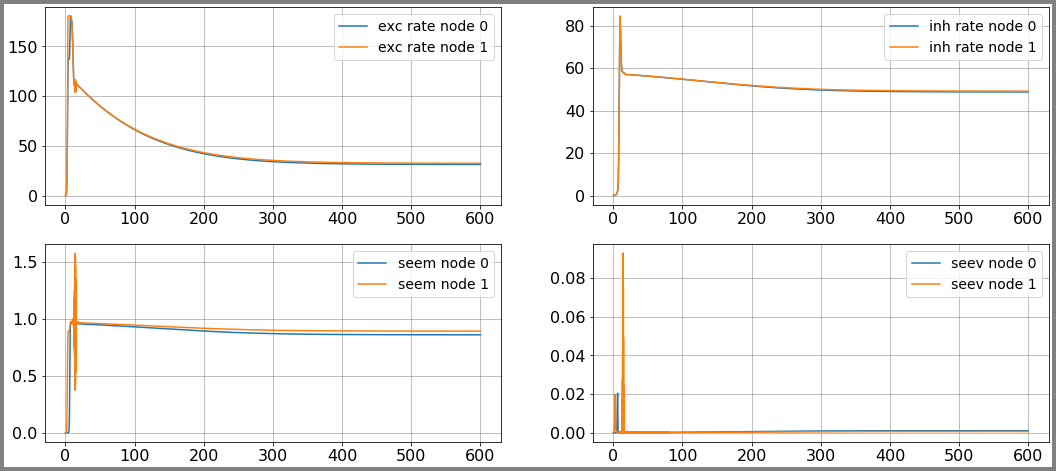

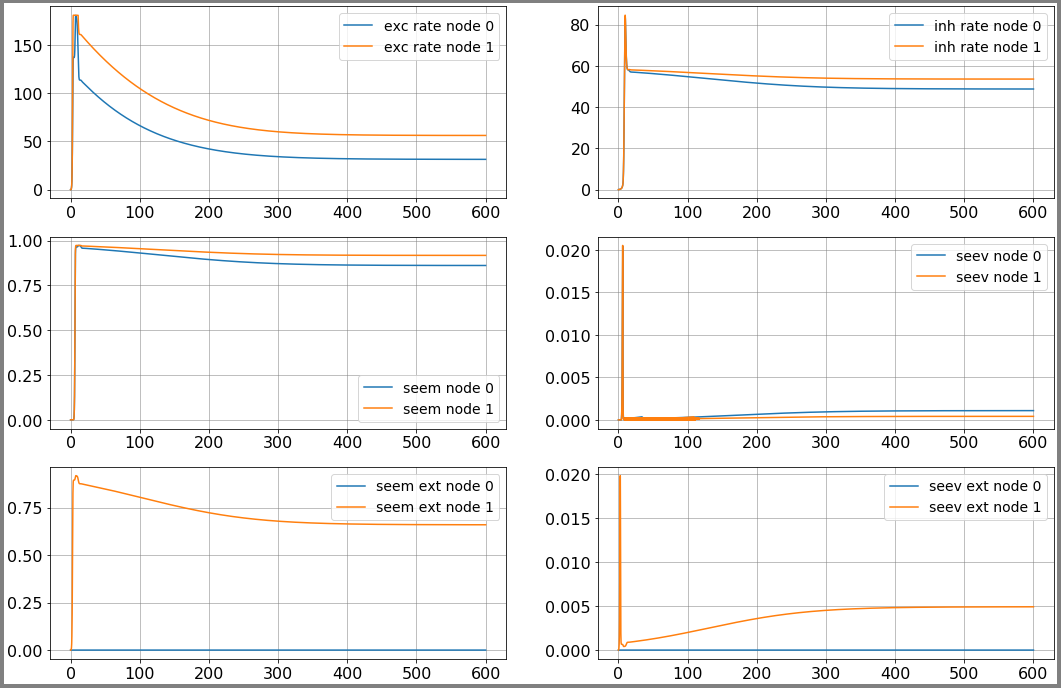

In [136]:
# up
dur = 600

for m in range(len(models)):
    models[m].params.duration = dur
    set_params_up(models[m])
    models[m].run(control=models[m].getZeroControl())
    plot_aln(models[m])

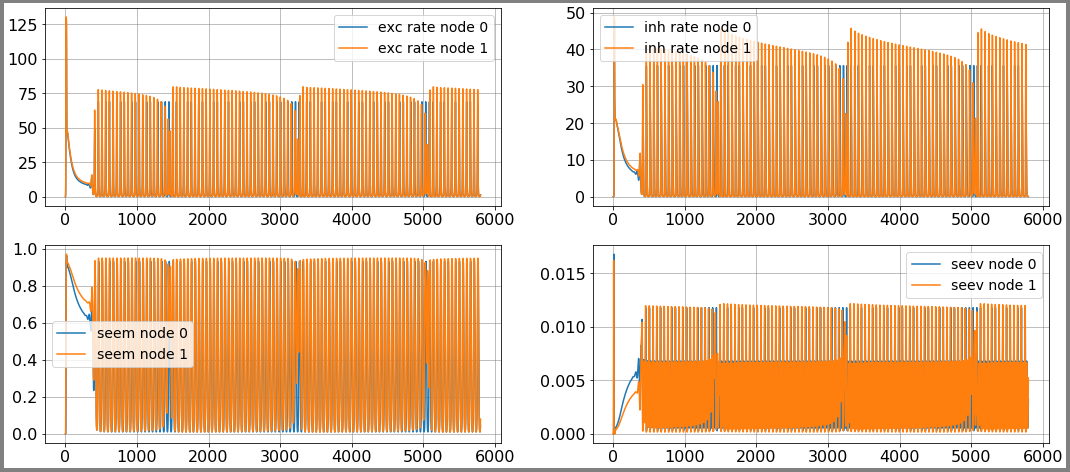

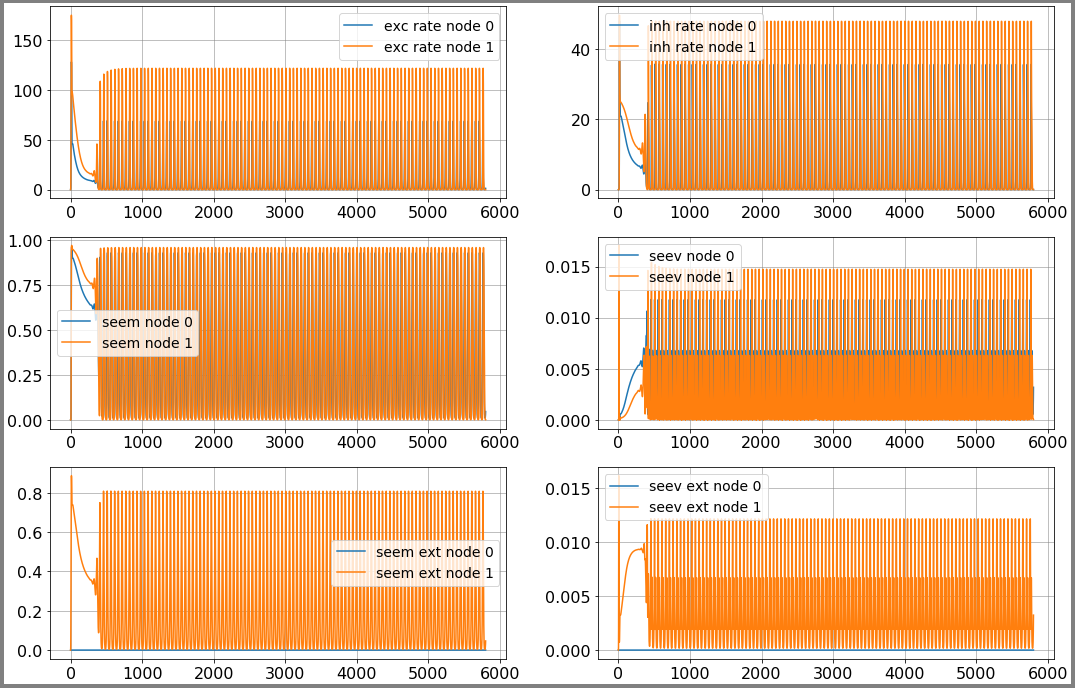

In [139]:
# fast oscillation
dur = 5800

for m in range(len(models)):
    models[m].params.duration = dur
    set_params_fast(models[m])
    models[m].run(control=models[m].getZeroControl())
    plot_aln(models[m])

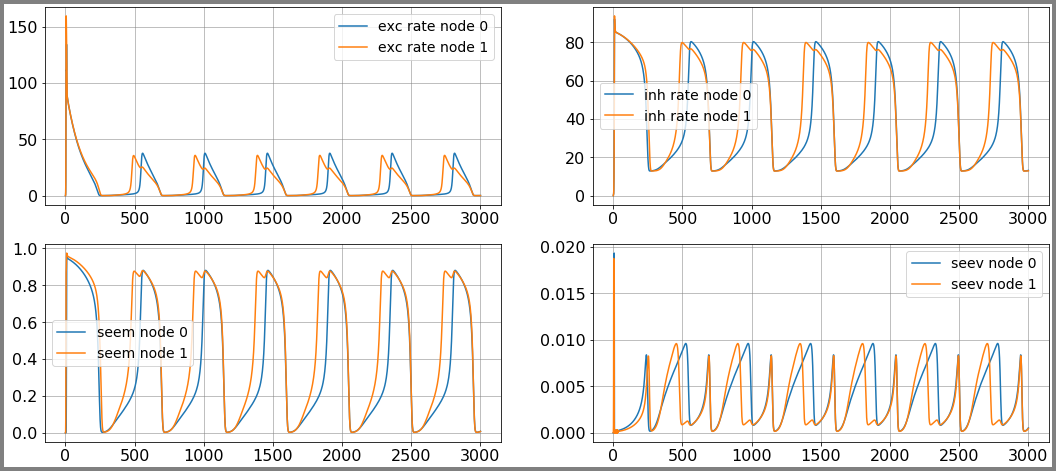

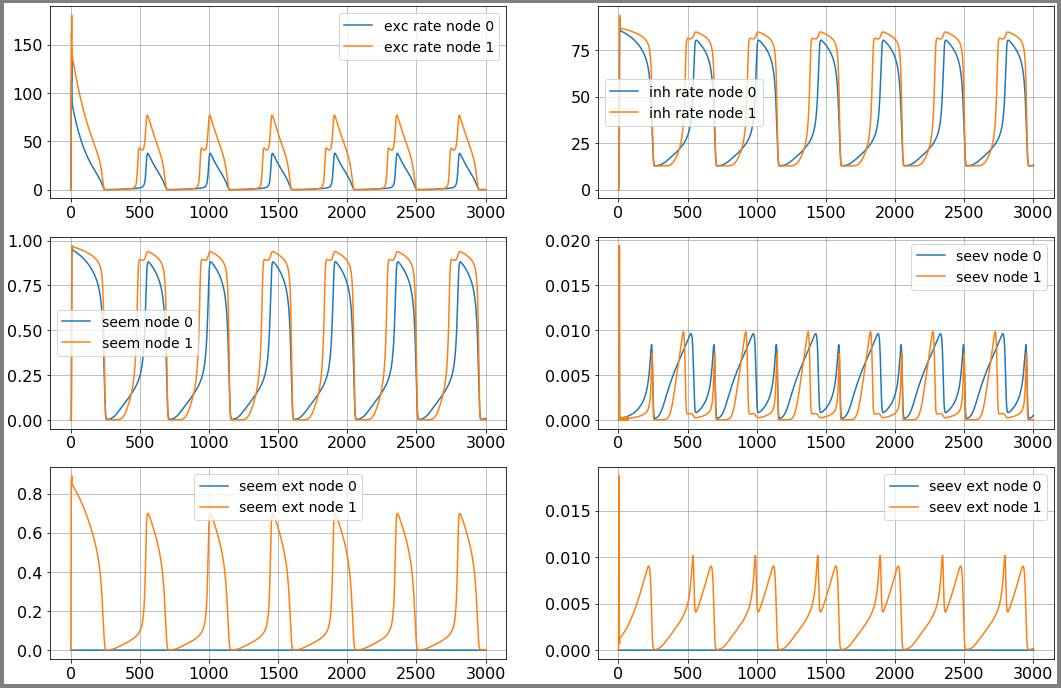

In [132]:
# slow oscillation
dur = 3000

for m in range(len(models)):
    models[m].params.duration = dur
    set_params_slow(models[m])
    models[m].run(control=models[m].getZeroControl())
    plot_aln(models[m])